In [28]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt
import bundle_adjust
import glob
import json
import rpcm
import sys
import cv2
from tqdm import tqdm
from PIL import Image
import time
import csv

sys.path.insert(0,'..')
print("ok")

os.environ["CUDA_VISIBLE_DEVICES"] = "1"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
ok


In [29]:
from bundle_adjust.cam_utils import SatelliteImage
from bundle_adjust.feature_tracks.ft_pair_ranking import select_optimal_pairs_to_match

img_dir = "/home/roger/sat-bundleadjust_github/logs/OMA_177/images"
img_paths = glob.glob(img_dir + "/*.tif")

images = [SatelliteImage(p, None, None) for p in img_paths]
n_images = len(images)
pairs_to_match = []
for i in range(n_images):
    for j in range(i + 1, n_images):
        pairs_to_match.append((i, j))

selected_pairs = select_optimal_pairs_to_match(pairs_to_match, images)

Computing DINO embeddings: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:02<00:00, 19.25it/s]

Found 5 trees of pairs connecting all cameras
Selected 205 pairs
Original number of pairs_to_match: 861
Number of pairs_to_match was reduced to 23.81%


[(0, 27),
 (0, 31),
 (1, 4),
 (1, 22),
 (1, 31),
 (2, 25),
 (2, 6),
 (3, 40),
 (3, 15),
 (4, 33),
 (5, 33),
 (6, 13),
 (6, 17),
 (7, 36),
 (7, 8),
 (8, 17),
 (9, 39),
 (9, 21),
 (9, 24),
 (10, 20),
 (11, 26),
 (11, 24),
 (11, 38),
 (11, 23),
 (12, 28),
 (12, 24),
 (13, 20),
 (13, 30),
 (14, 26),
 (15, 37),
 (15, 31),
 (16, 22),
 (17, 26),
 (17, 29),
 (18, 37),
 (19, 38),
 (20, 37),
 (25, 34),
 (27, 41),
 (29, 35),
 (32, 33),
 (0, 15),
 (1, 33),
 (1, 32),
 (2, 17),
 (2, 34),
 (3, 12),
 (3, 13),
 (3, 28),
 (4, 22),
 (4, 31),
 (5, 16),
 (5, 22),
 (6, 25),
 (7, 13),
 (8, 13),
 (9, 30),
 (10, 37),
 (11, 17),
 (11, 41),
 (13, 17),
 (13, 37),
 (14, 17),
 (15, 18),
 (17, 25),
 (17, 20),
 (18, 20),
 (18, 31),
 (19, 25),
 (19, 39),
 (20, 26),
 (20, 35),
 (20, 36),
 (20, 30),
 (21, 39),
 (22, 33),
 (23, 24),
 (24, 36),
 (25, 27),
 (26, 29),
 (26, 38),
 (36, 40),
 (0, 37),
 (0, 41),
 (0, 1),
 (2, 13),
 (2, 26),
 (3, 18),
 (4, 40),
 (4, 32),
 (5, 32),
 (6, 34),
 (6, 19),
 (7, 20),
 (8, 25),
 (8, 14

In [59]:
from bundle_adjust.cam_utils import SatelliteImage
from bundle_adjust.feature_tracks.ft_pair_ranking import select_optimal_pairs_to_match

img_dir = "/home/roger/sat-bundleadjust_github/logs/OMA_177/images"
img_paths = glob.glob(img_dir + "/*.tif")

images = [SatelliteImage(p, None, None) for p in img_paths]
n_images = len(images)
pairs_to_match = []
for i in range(n_images):
    for j in range(i + 1, n_images):
        pairs_to_match.append((i, j))

scores = []
for pair in pairs_to_match:
    img_idx_i, img_idx_j = pair
    score = cosine_similarity_np(embeddings[img_idx_i], embeddings[img_idx_j])
    scores.append(score)



[0.887239396572113, 0.9122257232666016, 0.8495359420776367, 0.8810517191886902, 0.8624800443649292, 0.8484114408493042, 0.8483429551124573, 0.8012893795967102, 0.9129813313484192, 0.7380558252334595, 0.7204433679580688, 0.8045084476470947, 0.9387840032577515, 0.8970509171485901, 0.8890454769134521, 0.8747744560241699, 0.8489094972610474, 0.8158851265907288, 0.8998043537139893, 0.8995232582092285, 0.864238977432251, 0.9021192789077759, 0.8947234153747559, 0.9042636752128601, 0.9380984306335449, 0.9235948920249939, 0.8696919679641724, 0.8991002440452576, 0.9094254374504089, 0.7095166444778442, 0.890145480632782, 0.9259892702102661, 0.7211755514144897, 0.9185818433761597, 0.8942140340805054, 0.7339096665382385, 0.9199524521827698, 0.7543043494224548, 0.9021041989326477, 0.9223564863204956, 0.9020894765853882, 0.8738503456115723, 0.8610267043113708, 0.8860928416252136, 0.8639275431632996, 0.765836238861084, 0.8299179077148438, 0.7807769179344177, 0.9061100482940674, 0.7456468343734741, 0.7

Computing DINO embeddings: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:02<00:00, 16.24it/s]


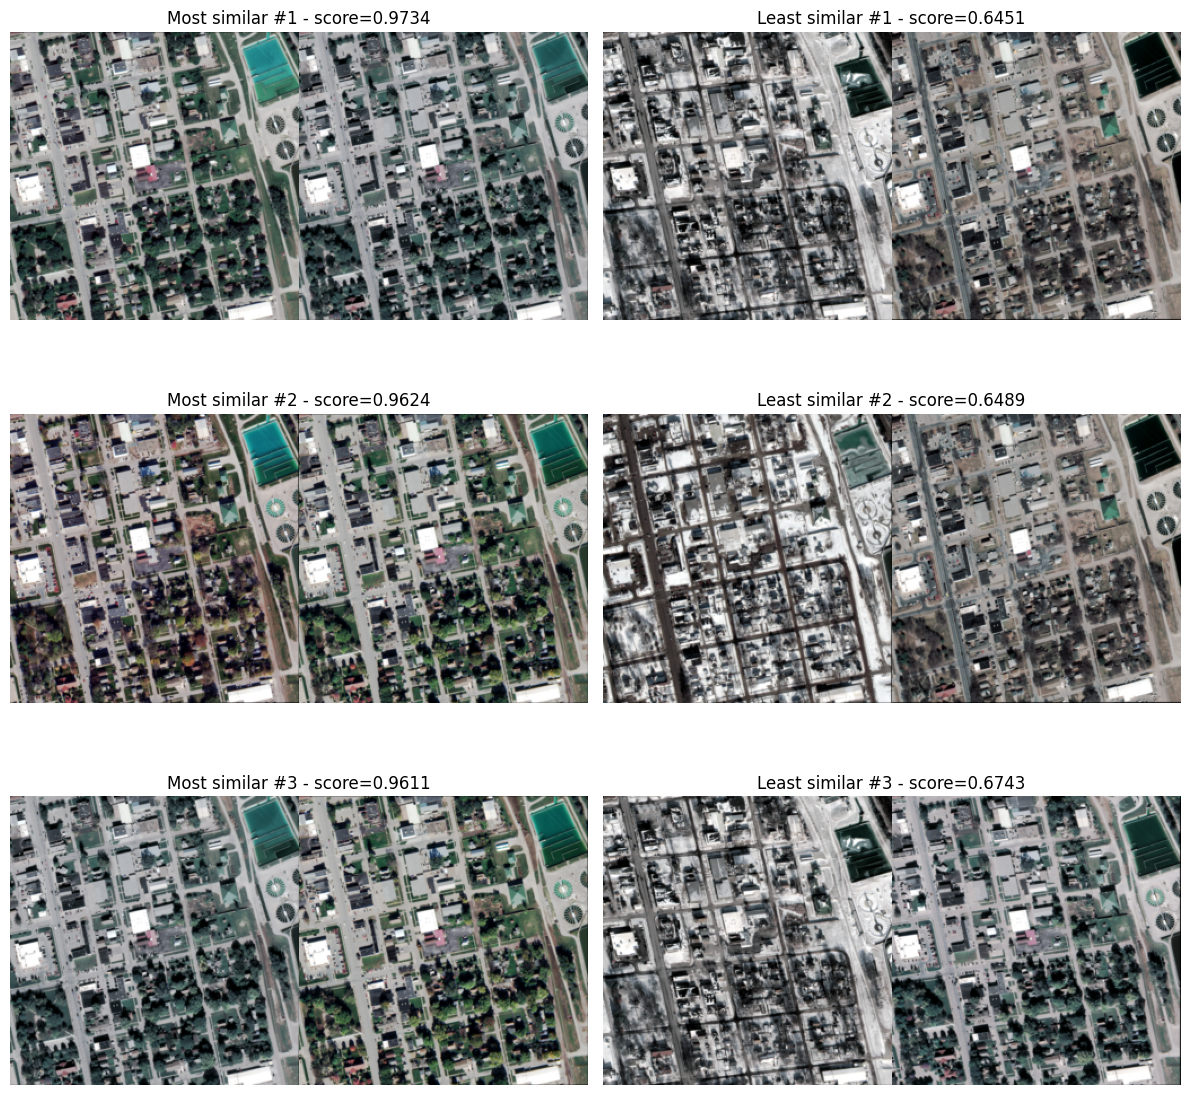

In [62]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from PIL import Image

from bundle_adjust.cam_utils import SatelliteImage
from bundle_adjust.feature_tracks.ft_pair_ranking import select_optimal_pairs_to_match
from bundle_adjust.feature_tracks.ft_pair_classifier import (
    extract_DINO_embeddings,
    cosine_similarity_np,
)

img_dir = "/home/roger/sat-bundleadjust_github/logs/OMA_177/images"
img_paths = sorted(glob.glob(img_dir + "/*.tif"))

images = [SatelliteImage(p, None, None) for p in img_paths]
n_images = len(images)

pairs_to_match = []
for i in range(n_images):
    for j in range(i + 1, n_images):
        pairs_to_match.append((i, j))

# Compute embeddings once
embeddings = extract_DINO_embeddings(images)

# Compute pairwise similarity scores
scores = []
for pair in pairs_to_match:
    img_idx_i, img_idx_j = pair
    score = cosine_similarity_np(embeddings[img_idx_i], embeddings[img_idx_j])
    scores.append(score)

scores = np.array(scores, dtype=float)

# Sort pair indices from least similar to most similar
indices_from_less_to_more_similar = np.argsort(scores)

least_similar_indices = indices_from_less_to_more_similar[:3]
most_similar_indices = indices_from_less_to_more_similar[-3:][::-1]


def read_tif_as_rgb_uint8(image_path):
    with rasterio.open(image_path) as src:
        arr = src.read()  # (C, H, W)

    # Convert to (H, W, C)
    arr = np.transpose(arr, (1, 2, 0))

    # Keep / construct 3 channels
    if arr.shape[2] == 1:
        arr = np.repeat(arr, 3, axis=2)
    elif arr.shape[2] >= 3:
        arr = arr[:, :, :3]
    else:
        raise ValueError(f"Unsupported number of channels in {image_path}: {arr.shape[2]}")

    # Normalize for display if needed
    if arr.dtype != np.uint8:
        arr = arr.astype(np.float32)
        arr_min = np.nanmin(arr)
        arr_max = np.nanmax(arr)
        if arr_max > arr_min:
            arr = ((arr - arr_min) / (arr_max - arr_min) * 255.0).clip(0, 255).astype(np.uint8)
        else:
            arr = np.zeros_like(arr, dtype=np.uint8)

    return arr


def resize_to_256(img):
    pil_img = Image.fromarray(img)
    pil_img = pil_img.resize((256, 256), Image.Resampling.BILINEAR)
    return np.array(pil_img)


def make_pair_image(pair):
    i, j = pair
    left = read_tif_as_rgb_uint8(img_paths[i])
    right = read_tif_as_rgb_uint8(img_paths[j])

    left = resize_to_256(left)
    right = resize_to_256(right)

    stacked = np.hstack([left, right])  # (256, 512, 3)
    return stacked


fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# Left column: 3 most similar
for row, idx in enumerate(most_similar_indices):
    pair = pairs_to_match[idx]
    score = scores[idx]
    stacked_img = make_pair_image(pair)

    ax = axes[row, 0]
    ax.imshow(stacked_img)
    ax.set_title(f"Most similar #{row+1} - score={score:.4f}")
    ax.axis("off")

# Right column: 3 least similar
for row, idx in enumerate(least_similar_indices):
    pair = pairs_to_match[idx]
    score = scores[idx]
    stacked_img = make_pair_image(pair)

    ax = axes[row, 1]
    ax.imshow(stacked_img)
    ax.set_title(f"Least similar #{row+1} - score={score:.4f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Toy example illustration

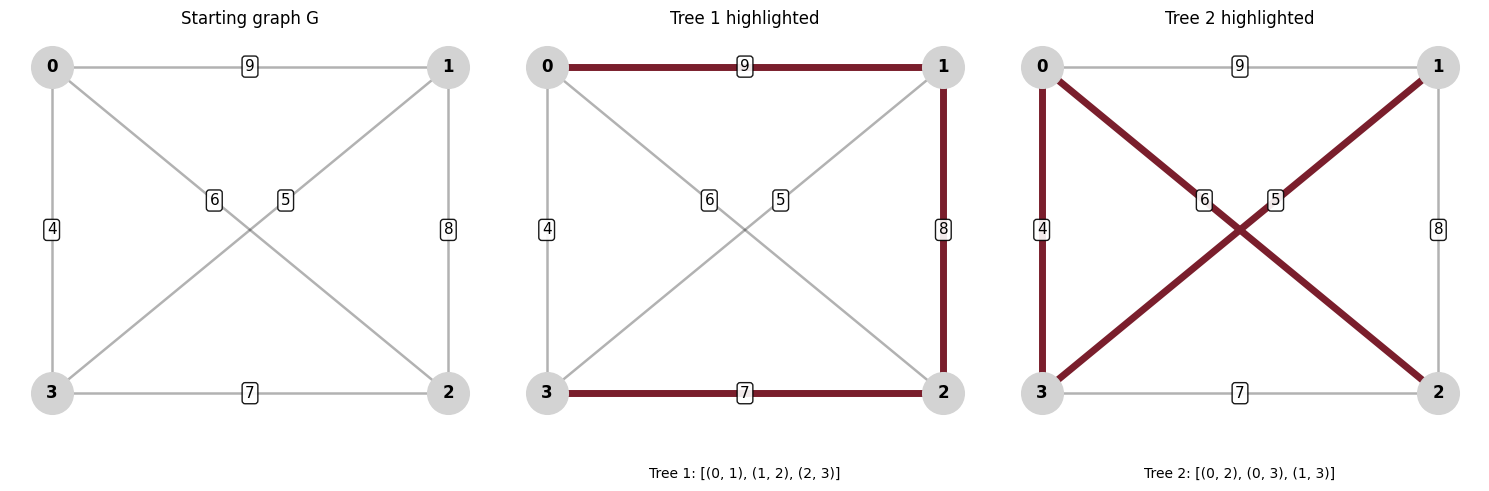

Tree 1 edges: [(0, 1), (1, 2), (2, 3)]
Tree 2 edges: [(0, 2), (0, 3), (1, 3)]


In [48]:
import matplotlib.pyplot as plt
import networkx as nx

# ------------------------------------------------------------
# Toy graph
# ------------------------------------------------------------
G = nx.Graph()
weighted_edges = [
    (0, 1, 9),
    (1, 2, 8),
    (2, 3, 7),
    (0, 2, 6),
    (1, 3, 5),
    (0, 3, 4),
]
G.add_weighted_edges_from(weighted_edges)

# Same layout in all panels
pos = {
    0: (-1.0,  1.0),
    1: ( 1.0,  1.0),
    2: ( 1.0, -1.0),
    3: (-1.0, -1.0),
}

# Compute tree 1
T1 = nx.maximum_spanning_tree(G, weight="weight")
tree1_edges = set(tuple(sorted(e)) for e in T1.edges())

# Remove tree 1 edges, compute tree 2
G_remaining = G.copy()
G_remaining.remove_edges_from(T1.edges())
T2 = nx.maximum_spanning_tree(G_remaining, weight="weight")
tree2_edges = set(tuple(sorted(e)) for e in T2.edges())


def midpoint(p1, p2, dx=0.0, dy=0.0):
    """Midpoint between p1 and p2, with optional offset."""
    return ((p1[0] + p2[0]) / 2 + dx, (p1[1] + p2[1]) / 2 + dy)


def draw_manual_edge_labels(ax, pos):
    """
    Draw labels manually so crossing edges do not create ambiguity.
    """
    label_specs = {
        (0, 1): {"text": "9", "xy": midpoint(pos[0], pos[1], dy=0.0)},
        (1, 2): {"text": "8", "xy": midpoint(pos[1], pos[2], dx=0.0)},
        (2, 3): {"text": "7", "xy": midpoint(pos[2], pos[3], dy=0.0)},
        (0, 3): {"text": "4", "xy": midpoint(pos[0], pos[3], dx=-0.0)},
        # Diagonals: deliberately separated
        (0, 2): {"text": "6", "xy": midpoint(pos[0], pos[2], dx=-0.18, dy=0.18)},
        (1, 3): {"text": "5", "xy": midpoint(pos[1], pos[3], dx=0.18, dy=0.18)},
    }

    for edge, spec in label_specs.items():
        ax.text(
            spec["xy"][0],
            spec["xy"][1],
            spec["text"],
            fontsize=11,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="black", alpha=0.9),
        )


def draw_graph_with_highlight(ax, graph, pos, title, highlight_edges=None, footer=None):
    if highlight_edges is None:
        highlight_edges = set()

    all_edges = [tuple(sorted((u, v))) for u, v in graph.edges()]
    normal_edges = [e for e in all_edges if e not in highlight_edges]
    highlighted_edges = [e for e in all_edges if e in highlight_edges]

    # Nodes
    nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=900, node_color="lightgray")
    nx.draw_networkx_labels(graph, pos, ax=ax, font_size=12, font_weight="bold")

    # Non-highlighted edges
    nx.draw_networkx_edges(
        graph,
        pos,
        ax=ax,
        edgelist=normal_edges,
        width=1.8,
        alpha=0.30,
    )

    # Highlighted edges
    if highlighted_edges:
        nx.draw_networkx_edges(
            graph,
            pos,
            ax=ax,
            edgelist=highlighted_edges,
            width=5,
            edge_color="#7A1E2C"
        )

    # Manual labels
    draw_manual_edge_labels(ax, pos)

    ax.set_title(title, fontsize=12)
    ax.set_axis_off()

    if footer:
        ax.text(
            0.5,
            -0.10,
            footer,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=10,
        )


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

draw_graph_with_highlight(
    axes[0],
    G,
    pos,
    title="Starting graph G",
)

draw_graph_with_highlight(
    axes[1],
    G,
    pos,
    title="Tree 1 highlighted",
    highlight_edges=tree1_edges,
    footer=f"Tree 1: {sorted(tree1_edges)}",
)

draw_graph_with_highlight(
    axes[2],
    G,
    pos,
    title="Tree 2 highlighted",
    highlight_edges=tree2_edges,
    footer=f"Tree 2: {sorted(tree2_edges)}",
)

plt.tight_layout()
plt.show()

print("Tree 1 edges:", sorted(tree1_edges))
print("Tree 2 edges:", sorted(tree2_edges))

saved


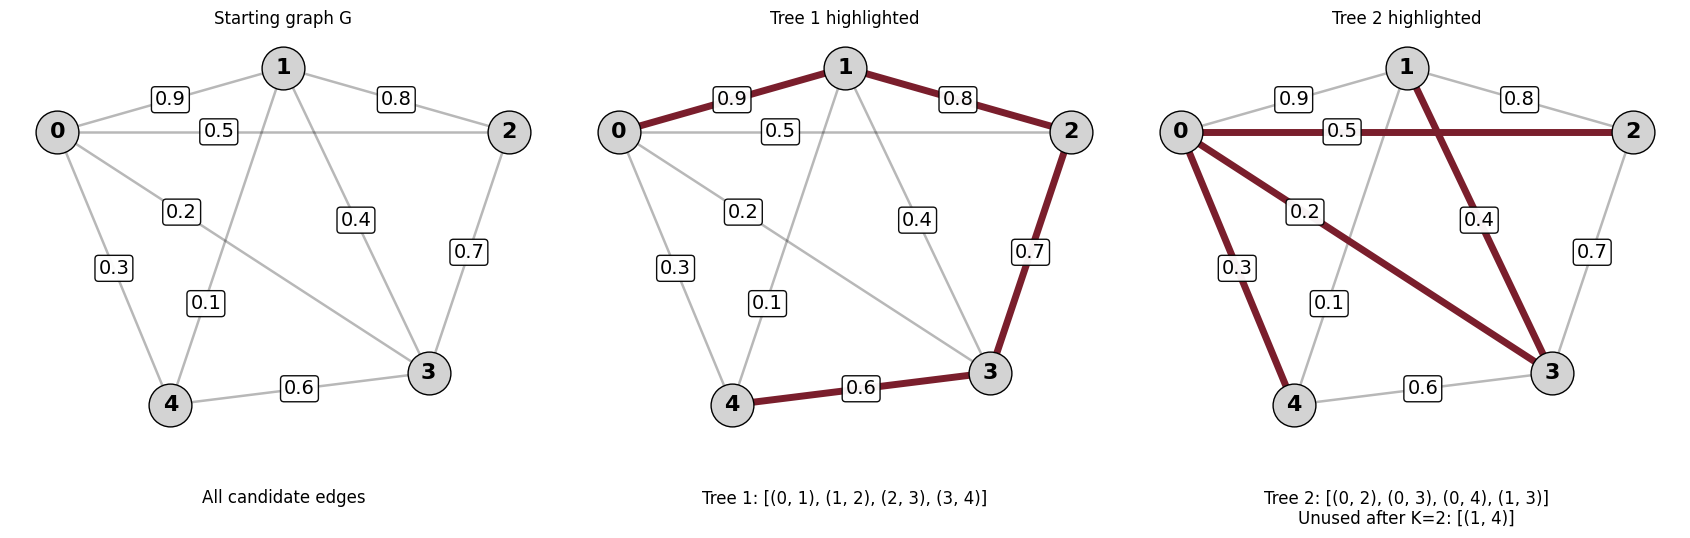

Tree 1 edges: [(0, 1), (1, 2), (2, 3), (3, 4)]
Tree 2 edges: [(0, 2), (0, 3), (0, 4), (1, 3)]
Edges not selected for K=2: [(1, 4)]


In [3]:
import matplotlib.pyplot as plt
import networkx as nx

# ------------------------------------------------------------
# More complex toy example with 5 nodes
# K = 2 spanning trees
#
# The graph is designed so that:
# - Tree 1 is selected from the strongest edges
# - Tree 2 is selected after removing Tree 1 edges
# - At least one edge remains in the graph but is NOT selected by K=2
# ------------------------------------------------------------

# Build weighted graph
G = nx.Graph()
weighted_edges = [
    (0, 1, 10),
    (1, 2, 9),
    (2, 3, 8),
    (3, 4, 7),
    (0, 2, 6),
    (1, 3, 5),
    (0, 4, 4),
    (0, 3, 3),
    (1, 4, 2),   # this one will remain unused after K=2
]
G.add_weighted_edges_from(weighted_edges)

# Fixed layout for consistent plotting
pos = {
    0: (-1.6,  0.8),
    1: (-0.2,  1.2),
    2: ( 1.2,  0.8),
    3: ( 0.7, -0.7),
    4: (-0.9, -0.9),
}

# ------------------------------------------------------------
# Compute Tree 1
# ------------------------------------------------------------
T1 = nx.maximum_spanning_tree(G, weight="weight")
tree1_edges = set(tuple(sorted(e)) for e in T1.edges())

# ------------------------------------------------------------
# Compute Tree 2 after removing Tree 1 edges
# ------------------------------------------------------------
G_remaining = G.copy()
G_remaining.remove_edges_from(T1.edges())

T2 = nx.maximum_spanning_tree(G_remaining, weight="weight")
tree2_edges = set(tuple(sorted(e)) for e in T2.edges())

# Remaining edges after K=2
G_after_k2 = G_remaining.copy()
G_after_k2.remove_edges_from(T2.edges())
remaining_edges_after_k2 = set(tuple(sorted(e)) for e in G_after_k2.edges())


def midpoint(p1, p2, dx=0.0, dy=0.0):
    return ((p1[0] + p2[0]) / 2 + dx, (p1[1] + p2[1]) / 2 + dy)


def draw_manual_edge_labels(ax, pos):
    """
    Manual label placement so labels stay readable.
    """
    label_specs = {
        (0, 1): {"text": "0.9", "xy": midpoint(pos[0], pos[1], dy=0.0)},
        (1, 2): {"text": "0.8",  "xy": midpoint(pos[1], pos[2], dy=0.0)},
        (2, 3): {"text": "0.7",  "xy": midpoint(pos[2], pos[3], dx=0.0)},
        (3, 4): {"text": "0.6",  "xy": midpoint(pos[3], pos[4], dy=0.0)},
        (0, 2): {"text": "0.5",  "xy": midpoint(pos[0], pos[2], dx=-0.4, dy=0.0)},
        (1, 3): {"text": "0.4",  "xy": midpoint(pos[1], pos[3], dx=0.0)},
        (0, 4): {"text": "0.3",  "xy": midpoint(pos[0], pos[4], dx=-0.0)},
        (0, 3): {"text": "0.2",  "xy": midpoint(pos[0], pos[3], dx=-0.38, dy=0.25)},
        (1, 4): {"text": "0.1",  "xy": midpoint(pos[1], pos[4], dx=-0.13, dy=-0.42)},
    }

    for spec in label_specs.values():
        ax.text(
            spec["xy"][0],
            spec["xy"][1],
            spec["text"],
            fontsize=14,
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="black", alpha=0.95),
        )


def draw_graph_with_highlight(ax, graph, pos, title, highlight_edges=None, footer=None):
    if highlight_edges is None:
        highlight_edges = set()

    all_edges = [tuple(sorted((u, v))) for u, v in graph.edges()]
    normal_edges = [e for e in all_edges if e not in highlight_edges]
    highlighted_edges = [e for e in all_edges if e in highlight_edges]

    # Nodes: light gray as requested
    nx.draw_networkx_nodes(
        graph,
        pos,
        ax=ax,
        node_size=950,
        node_color="lightgray",
        edgecolors="black",
        linewidths=1.0,
    )
    nx.draw_networkx_labels(
        graph,
        pos,
        ax=ax,
        font_size=16,
        font_weight="bold",
    )

    # Non-highlighted edges
    nx.draw_networkx_edges(
        graph,
        pos,
        ax=ax,
        edgelist=normal_edges,
        width=1.8,
        alpha=0.28,
    )

    # Highlighted edges
    if highlighted_edges:
        nx.draw_networkx_edges(
            graph,
            pos,
            ax=ax,
            edgelist=highlighted_edges,
            width=5,
            edge_color="#7A1E2C"
        )

    draw_manual_edge_labels(ax, pos)

    ax.set_title(title, fontsize=12)
    ax.set_axis_off()

    if footer:
        ax.text(
            0.5,
            -0.12,
            footer,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=12,
        )


fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

draw_graph_with_highlight(
    axes[0],
    G,
    pos,
    title="Starting graph G",
    footer="All candidate edges",
)

draw_graph_with_highlight(
    axes[1],
    G,
    pos,
    title="Tree 1 highlighted",
    highlight_edges=tree1_edges,
    footer=f"Tree 1: {sorted(tree1_edges)}",
)

draw_graph_with_highlight(
    axes[2],
    G,
    pos,
    title="Tree 2 highlighted",
    highlight_edges=tree2_edges,
    footer=(
        f"Tree 2: {sorted(tree2_edges)}\n"
        f"Unused after K=2: {sorted(remaining_edges_after_k2)}"
    ),
)

plt.tight_layout()

# Save high-resolution PNG
fig.savefig(
    "spanning_trees_toy_example.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)
print("saved")

plt.show()

print("Tree 1 edges:", sorted(tree1_edges))
print("Tree 2 edges:", sorted(tree2_edges))
print("Edges not selected for K=2:", sorted(remaining_edges_after_k2))